# Prática 1 - Monitoramento Inteligente de Pátio com Visão Computacional

**Curso de IA, Otimização e IoT para Indústrias e Negócios - Do Zero ao MLOps**

<div style="text-align:center; margin:24px 0 28px 0;">
  <img src="assets/pratica1_monitoramento_inteligente_patio.png" alt="Infográfico da Prática 1 - Monitoramento Inteligente de Pátio" style="width:100%; border-radius:14px; box-shadow:0 6px 20px rgba(15, 23, 42, 0.16);">
</div>

> **Do experimento ao serviço:** começamos executando o YOLO neste notebook; depois, a mesma inferência será disponibilizada por uma API e consumida por um cliente que simula uma câmera IoT.

Nesta prática, vamos simular uma câmera IoT utilizada para observar a movimentação de pessoas e veículos em um pátio. Usaremos um modelo YOLO pré-treinado para transformar imagens em informações que poderiam alimentar um painel, um alerta ou outro sistema.

A prática começa com a experimentação neste notebook. Na etapa seguinte, a mesma inferência será disponibilizada por meio de uma API.

## O desafio

Uma organização deseja acompanhar a movimentação em um pátio usando imagens capturadas por câmeras. Em vez de uma pessoa observar cada imagem, um modelo de visão computacional pode identificar automaticamente elementos de interesse.

Neste estudo inicial, queremos responder:

- há pessoas na cena?
- quantos veículos foram identificados?
- quais tipos de veículos aparecem?
- qual é a confiança de cada detecção?
- quais limitações aparecem quando a cena fica mais complexa?

## Objetivos de aprendizagem

Ao final deste notebook, você deverá ser capaz de:

- explicar o que é inferência em visão computacional;
- executar um modelo YOLO pré-treinado;
- interpretar classes, caixas delimitadoras e confiança;
- converter detecções em um resumo operacional;
- analisar o efeito do limiar de confiança;
- identificar limitações do modelo;
- explicar por que disponibilizar a inferência por uma API.

## Visão geral da prática

A prática completa possui três momentos:

1. **Experimento:** avaliamos o modelo diretamente no notebook.
2. **Servidor:** colocamos a inferência em uma API.
3. **Cliente:** simulamos uma câmera ou aplicação enviando imagens.

```text
Experimento: imagem -> YOLO -> detecções -> resumo

Aplicação: câmera/cliente -> API -> YOLO -> resposta -> painel ou alerta
```

> Neste notebook trabalharemos o primeiro momento e prepararemos a transição para a API.

## 1. Preparação do ambiente

Usaremos a biblioteca `ultralytics`, que fornece os modelos YOLO e uma interface para executar inferências.

In [1]:
#%pip install -q ultralytics

In [2]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from ultralytics import YOLO

## 2. Conhecendo as cenas

Foram selecionadas três imagens com dificuldade crescente:

1. um estacionamento visto de uma posição elevada;
2. uma rua com pessoas e veículos parcialmente ocluídos;
3. uma cena de tráfego misto com ônibus, bicicletas e pedestres.

A posição da câmera, a distância dos objetos, a iluminação e as oclusões podem afetar a detecção.

In [3]:
caminho_pratica_no_repositorio = Path("M4/mlops/pratica-01-monitoramento-inteligente-de-patio")
raizes_candidatas = [Path.cwd(), *Path.cwd().parents]
pastas_candidatas = []
for raiz in raizes_candidatas:
    pastas_candidatas.extend([
        raiz / "images/patio",
        raiz / caminho_pratica_no_repositorio / "images/patio",
    ])
pasta_imagens = next((pasta for pasta in pastas_candidatas if pasta.exists()), None)

if pasta_imagens is None:
    try:
        from google.colab import files
        print("Envie as três imagens da pasta images/patio.")
        arquivos_enviados = files.upload()
        caminhos_imagens = [Path(nome) for nome in arquivos_enviados]
        pasta_pratica = Path.cwd()
    except ImportError as erro:
        raise FileNotFoundError(
            "A pasta images/patio não foi encontrada. Abra o Jupyter na raiz do repositório ou na pasta da prática."
        ) from erro
else:
    pasta_pratica = pasta_imagens.parent.parent
    caminhos_imagens = [
        pasta_imagens / "patio_estacionamento.jpg",
        pasta_imagens / "patio_pessoas_veiculos.jpg",
        pasta_imagens / "patio_trafego_misto.jpg",
    ]

for caminho in caminhos_imagens:
    if not caminho.exists():
        raise FileNotFoundError(f"Imagem não encontrada: {caminho}")

print(f"{len(caminhos_imagens)} imagens carregadas.")

3 imagens carregadas.


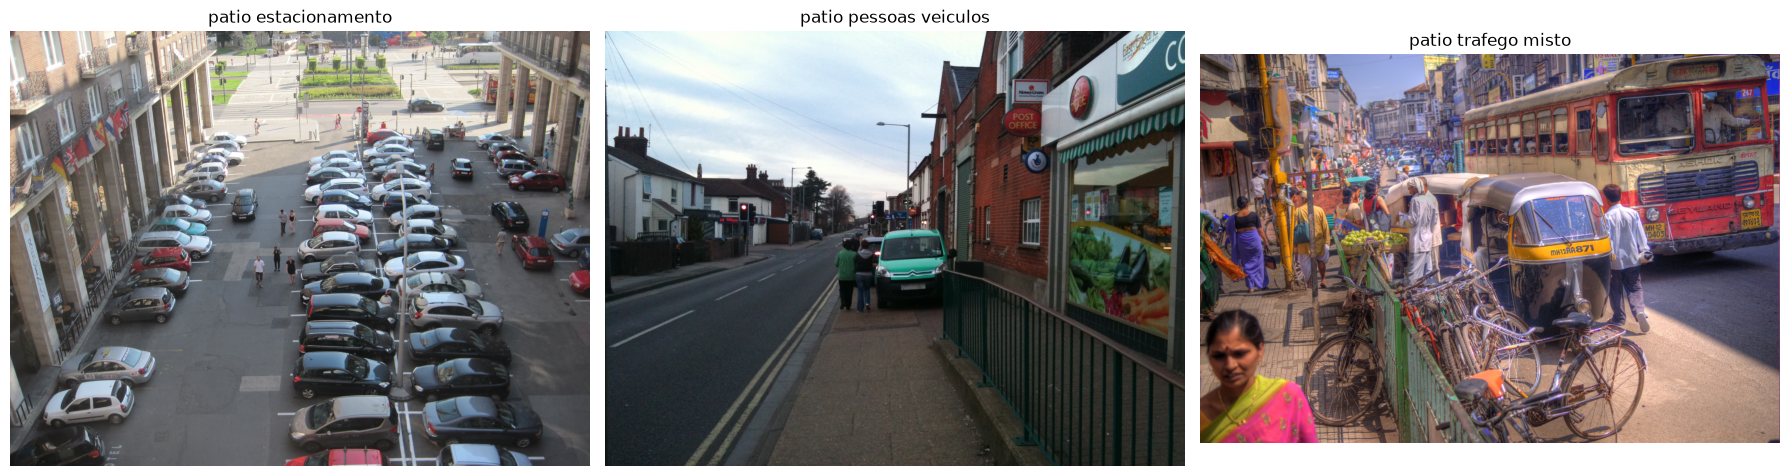

In [4]:
figura, eixos = plt.subplots(1, len(caminhos_imagens), figsize=(18, 6))

for eixo, caminho in zip(eixos, caminhos_imagens):
    eixo.imshow(Image.open(caminho))
    eixo.set_title(caminho.stem.replace("_", " "))
    eixo.axis("off")

plt.tight_layout()
plt.show()

### Antes de executar o modelo

Observe as imagens e formule uma hipótese:

- qual cena parece mais fácil para o modelo?
- em qual cena haverá mais objetos não detectados?
- objetos distantes serão identificados com a mesma confiança?

## 3. Carregamento do modelo

Usaremos o `yolov8n.pt`. A letra `n` indica a versão *nano*, menor e mais rápida. Ela é adequada para a demonstração e ajuda a introduzir a discussão sobre recursos computacionais limitados em dispositivos IoT.

O modelo foi treinado anteriormente em um conjunto de dados com classes de objetos comuns. Nós apenas executaremos a inferência.

In [5]:
caminho_modelo = pasta_pratica / "yolov8n.pt"
modelo = YOLO(str(caminho_modelo))
print("Modelo carregado com sucesso.")

Modelo carregado com sucesso.


## 4. Transformando detecções em informação

Uma imagem com caixas é útil para inspeção visual. Uma aplicação, porém, geralmente precisa de dados estruturados.

A função abaixo executa o modelo e produz:

- a imagem anotada;
- uma tabela com classe, confiança e coordenadas;
- uma contagem por tipo de objeto.

In [6]:
CLASSES_DE_INTERESSE = {
    "person": "pessoa",
    "bicycle": "bicicleta",
    "car": "carro",
    "motorcycle": "motocicleta",
    "bus": "ônibus",
    "truck": "caminhão",
}

def analisar_cena(caminho_imagem, confianca_minima=0.35):
    resultado = modelo.predict(
        source=str(caminho_imagem),
        conf=confianca_minima,
        verbose=False,
    )[0]

    deteccoes = []
    for caixa in resultado.boxes:
        id_classe = int(caixa.cls.item())
        classe_original = resultado.names[id_classe]
        if classe_original not in CLASSES_DE_INTERESSE:
            continue

        deteccoes.append({
            "classe": CLASSES_DE_INTERESSE[classe_original],
            "confianca": round(float(caixa.conf.item()), 3),
            "caixa_xyxy": [round(valor, 1) for valor in caixa.xyxy[0].tolist()],
        })

    contagens = Counter(deteccao["classe"] for deteccao in deteccoes)
    return {
        "arquivo": Path(caminho_imagem).name,
        "imagem_anotada": resultado.plot()[:, :, ::-1],
        "deteccoes": deteccoes,
        "contagens": dict(contagens),
        "total": len(deteccoes),
    }

## 5. Análise da primeira cena

Começaremos pelo estacionamento. Usaremos confiança mínima de 35% para não eliminar imediatamente objetos pequenos ou distantes.

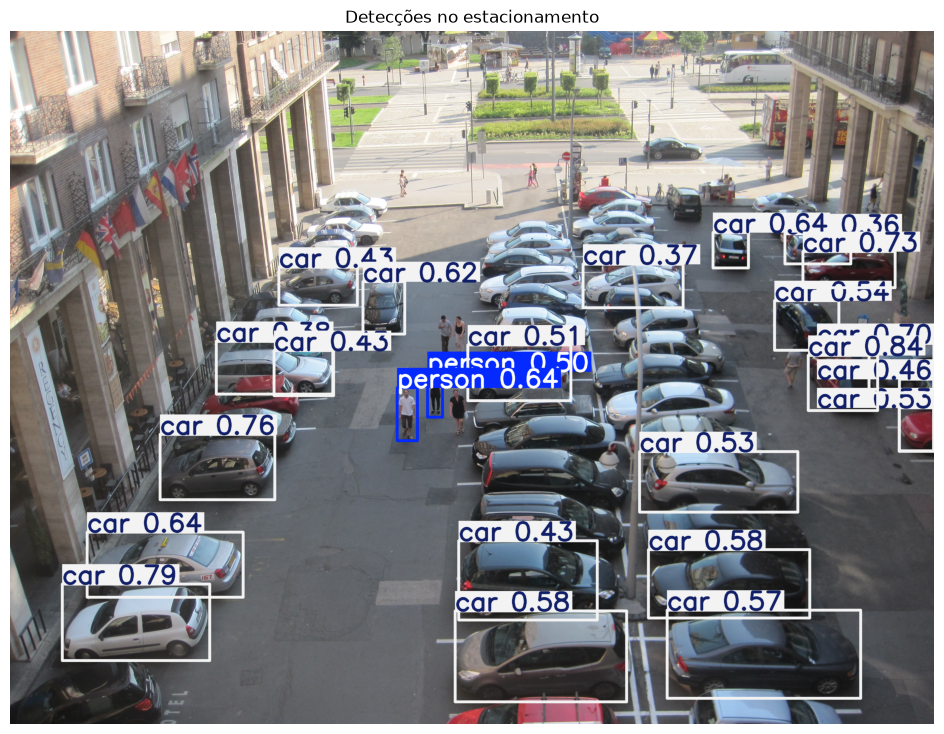

Resumo operacional:
Arquivo: patio_estacionamento.jpg
Total de objetos de interesse: 24
Contagem por classe: {'carro': 22, 'pessoa': 2}


In [7]:
analise = analisar_cena(caminhos_imagens[0], confianca_minima=0.35)

plt.figure(figsize=(14, 9))
plt.imshow(analise["imagem_anotada"])
plt.title("Detecções no estacionamento")
plt.axis("off")
plt.show()

print("Resumo operacional:")
print(f"Arquivo: {analise['arquivo']}")
print(f"Total de objetos de interesse: {analise['total']}")
print(f"Contagem por classe: {analise['contagens']}")

In [8]:
tabela_deteccoes = pd.DataFrame(analise["deteccoes"])
tabela_deteccoes

,classe,confianca,caixa_xyxy
0,carro,0.844,"[3151.2, 1280.9, 3425.7, 1498.3]"
1,carro,0.794,"[206.1, 2183.3, 788.7, 2485.3]"
2,carro,0.765,"[592.0, 1592.9, 1045.8, 1850.5]"
3,carro,0.734,"[3130.6, 870.0, 3494.9, 1013.7]"
4,carro,0.696,"[3391.1, 1233.9, 3647.5, 1428.4]"
5,carro,0.645,"[304.3, 1978.6, 920.8, 2235.5]"
6,carro,0.640,"[2775.1, 796.0, 2915.6, 935.3]"
7,pessoa,0.639,"[1528.5, 1408.6, 1608.5, 1617.5]"
8,carro,0.619,"[1393.8, 989.9, 1558.9, 1196.4]"
9,carro,0.585,"[2520.6, 2048.0, 3157.9, 2317.8]"


### Interpretação

Compare a contagem do modelo com sua inspeção visual. Não espere correspondência perfeita. Carros parcialmente escondidos, pessoas muito pequenas e objetos próximos às bordas podem não ser detectados.

A confiança não representa uma garantia de acerto. Ela é um valor produzido pelo modelo e deve ser interpretada no contexto da aplicação.

## 6. Comparação entre as cenas

Agora executaremos exatamente a mesma função nas três imagens. Isso nos permite observar como o comportamento muda conforme a perspectiva e a complexidade da cena.

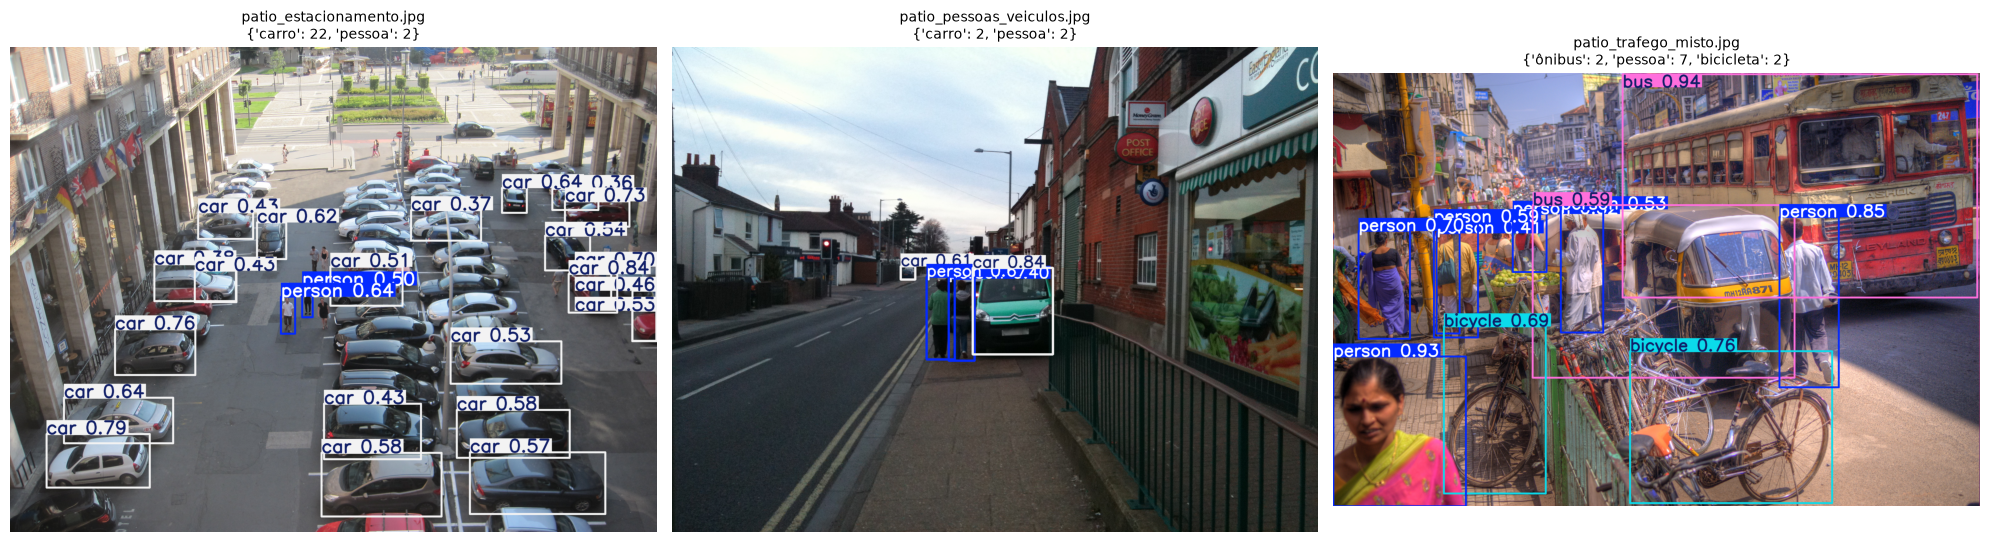

In [9]:
analises = [analisar_cena(caminho, confianca_minima=0.35) for caminho in caminhos_imagens]
figura, eixos = plt.subplots(1, len(analises), figsize=(20, 7))

for eixo, item in zip(eixos, analises):
    eixo.imshow(item["imagem_anotada"])
    eixo.set_title(f"{item['arquivo']}\n{item['contagens']}", fontsize=10)
    eixo.axis("off")

plt.tight_layout()
plt.show()

In [10]:
resumo_cenas = pd.DataFrame([
    {"arquivo": item["arquivo"], "total": item["total"], **item["contagens"]}
    for item in analises
]).fillna(0)

resumo_cenas

,arquivo,total,carro,pessoa,ônibus,bicicleta
0,patio_estacionamento.jpg,24,22.0,2,0.0,0.0
1,patio_pessoas_veiculos.jpg,4,2.0,2,0.0,0.0
2,patio_trafego_misto.jpg,11,0.0,7,2.0,2.0


## 7. Efeito do limiar de confiança

O limiar define quais detecções serão aceitas. Reduzi-lo pode recuperar objetos difíceis, mas também pode aumentar previsões incorretas. Aumentá-lo reduz detecções duvidosas, mas pode ocultar objetos reais.

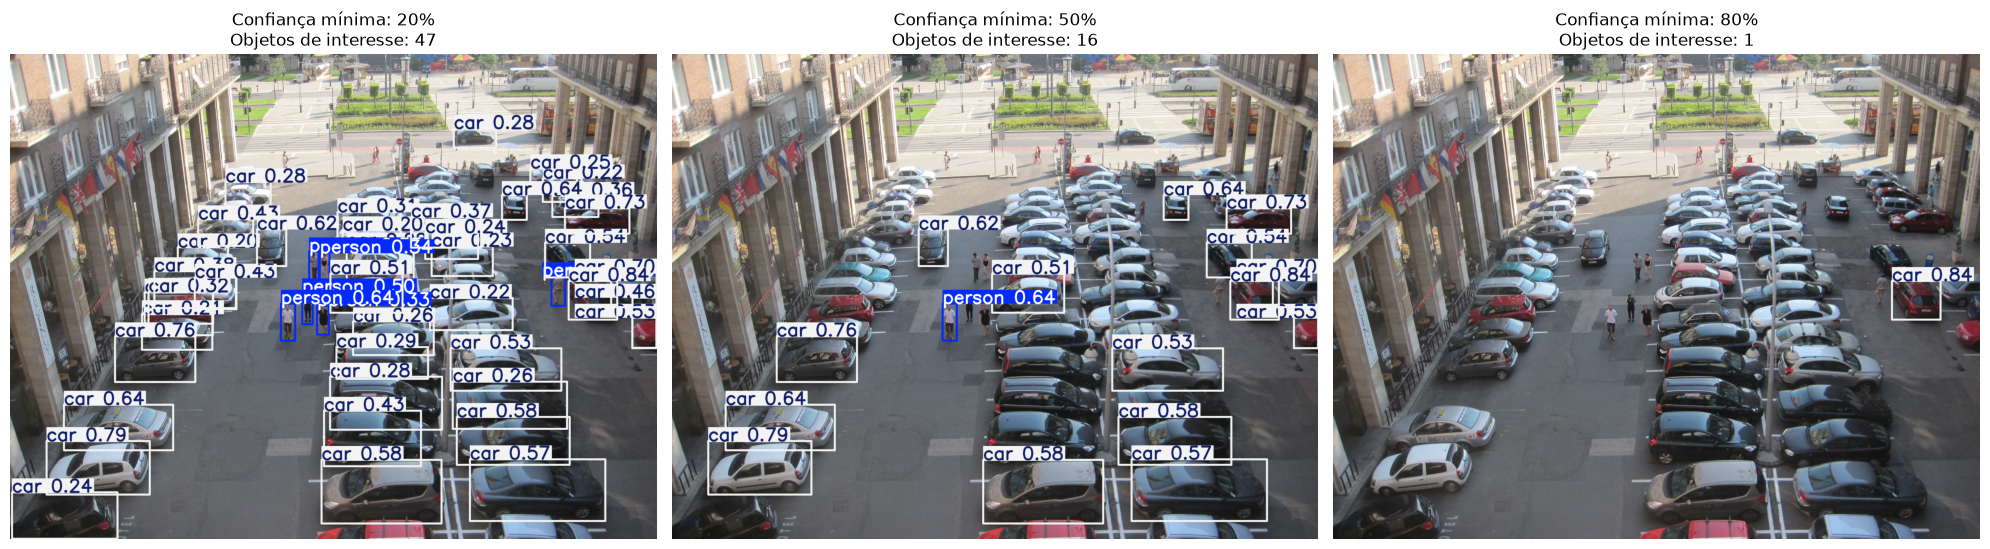

In [11]:
limiares = [0.20, 0.50, 0.80]
figura, eixos = plt.subplots(1, len(limiares), figsize=(20, 7))

for eixo, limiar in zip(eixos, limiares):
    item = analisar_cena(caminhos_imagens[0], confianca_minima=limiar)
    eixo.imshow(item["imagem_anotada"])
    eixo.set_title(
        f"Confiança mínima: {limiar:.0%}\n"
        f"Objetos de interesse: {item['total']}"
    )
    eixo.axis("off")

plt.tight_layout()
plt.show()

### Decisão de negócio

Não existe um limiar universalmente correto. A escolha depende do custo dos erros.

- Se deixar de identificar uma pessoa for muito grave, pode ser necessário aceitar mais detecções duvidosas.
- Se um falso alerta interromper uma operação, pode ser necessário exigir maior confiança.

Essa decisão deve ser validada com imagens representativas do ambiente real.

## 8. Uma regra operacional simples

Para ilustrar como uma previsão pode alimentar outro sistema, criaremos uma regra demonstrativa. Ela não deve ser interpretada como uma regra de segurança real.

In [12]:
def gerar_status_operacional(contagens):
    pessoas = contagens.get("pessoa", 0)
    veiculos = sum(
        contagens.get(classe, 0)
        for classe in ["carro", "motocicleta", "ônibus", "caminhão"]
    )

    if pessoas > 0 and veiculos > 0:
        return "ATENÇÃO: pessoas e veículos identificados na mesma cena"
    if veiculos > 0:
        return "Movimentação de veículos identificada"
    if pessoas > 0:
        return "Movimentação de pessoas identificada"
    return "Nenhum objeto de interesse identificado"

for item in analises:
    print(f"{item['arquivo']}: {gerar_status_operacional(item['contagens'])}")

patio_estacionamento.jpg: ATENÇÃO: pessoas e veículos identificados na mesma cena
patio_pessoas_veiculos.jpg: ATENÇÃO: pessoas e veículos identificados na mesma cena
patio_trafego_misto.jpg: ATENÇÃO: pessoas e veículos identificados na mesma cena


> **Importante:** uma detecção em uma imagem isolada não demonstra proximidade, direção, velocidade ou risco. Uma aplicação real exigiria definição de regiões da imagem, análise temporal, validação e regras operacionais desenvolvidas com especialistas.

## 9. Limitações observadas

O experimento ajuda a revelar limitações importantes:

- objetos pequenos ou distantes podem não ser detectados;
- oclusões dificultam a identificação;
- o modelo conhece apenas as classes presentes em seu treinamento;
- veículos regionais podem ser confundidos com classes conhecidas;
- uma imagem isolada não permite acompanhar o mesmo objeto ao longo do tempo;
- contagem por detecção não equivale automaticamente à ocupação real do pátio.

Essas limitações não tornam o modelo inútil. Elas determinam como ele pode ou não ser utilizado.

## 10. Do notebook à API

Neste experimento, uma pessoa abre o notebook, escolhe a imagem e executa as células. Uma câmera ou aplicação externa não deve depender desse processo manual.

Na próxima etapa:

1. um cliente enviará uma imagem;
2. a API receberá o arquivo no endpoint `POST /predict`;
3. o servidor executará a função de inferência;
4. a resposta devolverá as detecções e o resumo operacional.

O contrato esperado poderá ser semelhante a:

```json
{
  "arquivo": "patio.jpg",
  "contagens": {"pessoa": 3, "carro": 12},
  "total": 15,
  "status": "ATENÇÃO: pessoas e veículos identificados na mesma cena"
}
```

## Para Praticar

1. Compare a contagem visual com a contagem do modelo nas três cenas.
2. Identifique pelo menos um falso negativo ou possível classificação incorreta.
3. Escolha um limiar de confiança para o case e justifique.
4. Explique por que a regra operacional apresentada não deve ser usada como regra de segurança real.
5. Descreva quais dados você gostaria de receber de uma API para integrar esse modelo a um painel.

## Conclusão

Neste notebook, transformamos imagens em detecções e depois em informação operacional. Também observamos que o resultado depende da cena, do limiar e das classes conhecidas pelo modelo.

Disponibilizar essa inferência por uma API será o próximo passo. Tracking, registro de modelos, versionamento, monitoramento e model cards serão conectados nas demais práticas do curso.

## Créditos das imagens

Imagens obtidas no Wikimedia Commons e incluídas para uso educacional:

- `patio_estacionamento.jpg`: Bence Damokos, licença CC BY-SA 3.0.
- `patio_pessoas_veiculos.jpg`: PeterEastern, licença CC BY-SA 3.0.
- `patio_trafego_misto.jpg`: Ville Miettinen, licença CC BY 2.0.

As páginas de origem estão registradas nos metadados deste notebook.